# STEP 0:
## SELECT A COMPANY

In [ ]:
# 1. SETUP 

import pandas as pd

# Load the new extended dataset for Assignment 2
df = pd.read_csv('Symbol_Info_extended.csv')

# Justification for country selection:
# My Student ID ends with '0', which assigns me to Group 1 (LATAM & Offshore).
# Therefore, I must filter the dataset to include only companies from Brazil, Mexico, Cayman Islands, and Bermuda.
assigned_countries = ['Brazil', 'Mexico', 'Cayman Islands', 'Bermuda']

# Filter the dataset for Group 1 countries
df_group = df[df['country'].isin(assigned_countries)].copy()

# Display the ENTIRE dataframe for the assigned group to review all available metrics before making a final decision.
print(f"Total companies in Group 1: {len(df_group)}")
display(df_group)

Total companies in Group 1: 57


,symbol,company_name,sector,industry,country,market_cap,net_income,total_revenue,return_on_assets,return_on_equity,...,pe_trailing,pe_forward,earnings_growth,price_to_sales,price_to_book,revenue_growth,debt_to_equity,dividend_yield,payout_ratio,free_cashflow
12,ABEV,Ambev S.A.,Consumer Defensive,Beverages - Brewers,Brazil,4.983262e+10,1.557772e+10,8.820957e+10,0.09784,0.17251,...,16.000000,14.274244,0.024,0.564934,2.776781,-0.001,3.420,4.8300,0.8049,1.820394e+10
25,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,Bermuda,3.364622e+10,4.832000e+09,1.977700e+10,0.04568,0.21306,...,7.407692,9.725809,0.946,1.701280,1.449123,-0.033,11.282,NaN,0.0000,5.276125e+09
83,AGO,Assured Guaranty Ltd.,Financial Services,Insurance - Specialty,Bermuda,3.404879e+09,4.110000e+08,8.140000e+08,0.01501,0.07896,...,8.807561,10.035580,-0.445,4.182898,0.618355,-0.062,30.643,1.9800,0.1604,1.847500e+08
167,AMX,"América Móvil, S.A.B. de C.V.",Communication Services,Telecom Services,Mexico,7.858860e+10,8.751720e+10,9.484443e+11,0.06641,0.21128,...,15.652695,12.668288,0.258,0.082861,3.679852,0.021,170.868,2.1600,0.3606,1.402851e+11
232,ASC,Ardmore Shipping Corporation,Industrials,Marine Shipping,Bermuda,7.683133e+08,5.403100e+07,3.241170e+08,0.05540,0.09023,...,14.265151,22.023392,3.164,2.370481,1.173355,0.188,16.052,3.4500,0.2348,-6.637175e+07
295,AXS,AXIS Capital Holdings Limited,Financial Services,Insurance - Specialty,Bermuda,7.367900e+09,1.039344e+09,6.685203e+09,0.02589,0.17415,...,7.469358,6.885837,0.456,1.102121,1.267309,0.080,23.409,1.7600,0.1315,6.762950e+07
308,BAK,Braskem S.A.,Basic Materials,Chemicals,Brazil,1.924679e+09,-9.132000e+09,6.674500e+10,0.00071,NaN,...,NaN,-9.010858,1.072,0.028836,-0.613344,-0.204,NaN,NaN,0.0000,-6.892625e+09
323,BBD,Banco Bradesco S.A.,Financial Services,Banks - Regional,Brazil,3.668037e+10,2.324582e+10,9.167085e+10,0.01046,0.13366,...,8.261905,6.260261,-0.075,0.400131,1.032714,0.105,NaN,4.7700,0.5907,NaN
327,BBUC,Brookfield Business Corporation,Industrials,Conglomerates,Bermuda,6.948477e+09,-6.600000e+07,2.714400e+10,0.03378,0.02285,...,NaN,12.992279,-0.486,0.255986,1.271154,-0.046,293.827,0.7400,0.0309,2.613750e+09
415,BNT,Brookfield Wealth Solutions Ltd.,Financial Services,Insurance - Diversified,Bermuda,1.243737e+10,4.830000e+08,1.067300e+10,0.00737,0.03632,...,16.543797,NaN,NaN,1.165312,0.910735,-0.367,51.619,0.6200,0.0913,8.925875e+09


In [ ]:
# 2. COMPANY SELECTION AND JUSTIFICATION

# I have selected Petroleo Brasileiro S.A. (Petrobras), ticker: PBR-A.
# Justification for this choice:
# 1. Market Cap and Industry Position: It is a massive player in the LATAM Energy sector, providing highly reliable, liquid, and globally relevant financial data.
# 2. Profitability vs Valuation: Petrobras typically exhibits massive profit margins and strong free cash flow, yet it often trades at a uniquely low P/E ratio due to regional and political risk premiums. 
# 3. Beta and Macro impact: Analyzing its fundamental strength alongside its beta will provide excellent insights into how geopolitical energy cycles affect LATAM valuations.
# This contrast makes it a perfect, complex candidate for a fundamental deep dive.

selected_symbol = 'PBR-A'

# Extract the specific row for the selected company
my_company = df_group[df_group['symbol'] == selected_symbol]

print("\n--- SELECTED COMPANY FOR DEEP DIVE ---")
display(my_company)


--- SELECTED COMPANY FOR DEEP DIVE ---


,symbol,company_name,sector,industry,country,market_cap,net_income,total_revenue,return_on_assets,return_on_equity,...,pe_trailing,pe_forward,earnings_growth,price_to_sales,price_to_book,revenue_growth,debt_to_equity,dividend_yield,payout_ratio,free_cashflow
2102,PBR-A,Petróleo Brasileiro S.A. - Petrobras,Energy,Oil & Gas Integrated,Brazil,1.213202e+11,1.075830e+11,4.980910e+11,0.08231,0.25601,...,5.469136,7.203252,-0.072,0.24357,1.36926,0.004,83.269,9.92,0.4158,8.293275e+10


# STEP 1:
## DATA PREPARATION

In [ ]:
# 3. CREATION OF WORKING DATAFRAME WITH ONLY THE REQUIRED VARIABLES

# Numpy is the fundamental library in Python for performing advanced mathematical calculations.
import numpy as np


# Filtering the dataset to retain only the required variables

required_columns = [
    'symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap',
    'return_on_assets', 'return_on_equity', 'profit_margins',
    'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow'
]
df_working = df_group[required_columns].copy()

# Replace infinite values with NaN
# Infinite values (e.g., from dividing by zero revenue) are invalid observations and must not be treated as large numbers.
df_working = df_working.replace([np.inf, -np.inf], np.nan)


# Filtering out invalid market capitalizations
# Market cap <= 0 indicates a data quality issue, not a small company.
# Therefore, we drop these rows completely before any peer selection.
df_working = df_working[df_working['market_cap'] > 0].copy()


# Cleaning valuation multiples (pe_trailing and price_to_book)
# Negative P/E (losses) or negative P/B (negative equity) are structurally different from positive multiples. 
# They cannot be compared on the same scale, so they are set to NaN.
df_working.loc[df_working['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
df_working.loc[df_working['price_to_book'] <= 0, 'price_to_book'] = np.nan

# Note on handling missing values: Per assignment rules, missing values will only be dropped 
# when analyzing a specific metric in later steps. No data imputation will be performed.

# Display the final cleaned row for our selected company (PBR-A) to confirm success
pbr_cleaned = df_working[df_working['symbol'] == 'PBR-A']
display(pbr_cleaned)

,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
2102,PBR-A,Petróleo Brasileiro S.A. - Petrobras,Energy,Oil & Gas Integrated,Brazil,1.213202e+11,0.08231,0.25601,0.21599,5.469136,1.36926,0.004,83.269,8.293275e+10


# STEP 2:
## BUILD PEER GROUPS

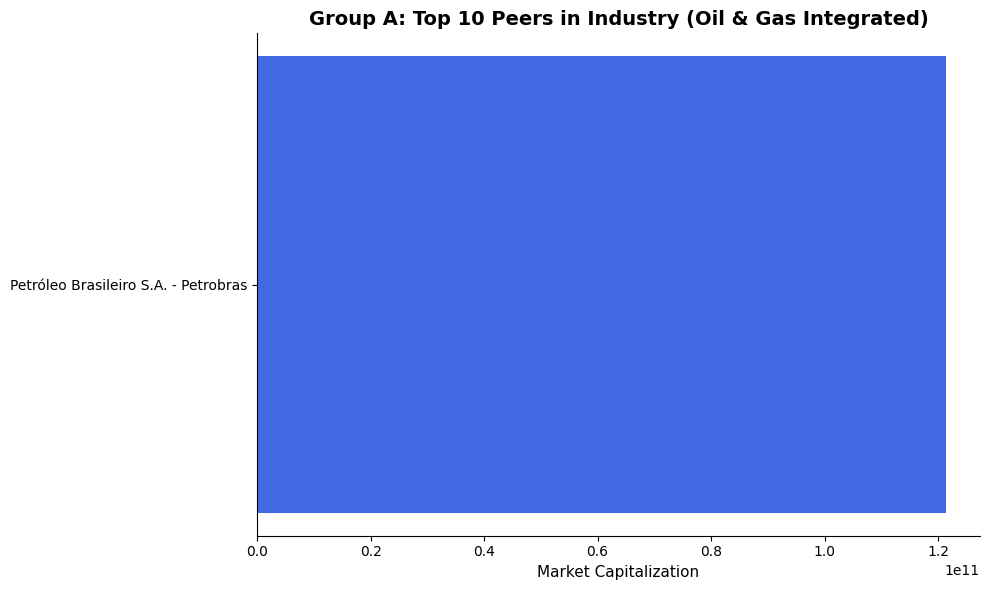

In [ ]:
# 4. COMPARISON GROUPS
# GROUP A - SAME INDUSTRY

import matplotlib.pyplot as plt

# Identifing the industry of the selected company
selected_symbol = 'PBR-A'
pbr_industry = df_working.loc[df_working['symbol'] == selected_symbol, 'industry'].values[0]

# Creating a clean display label column (Fallback to symbol if company_name is missing)
df_working['display_name'] = df_working['company_name'].fillna(df_working['symbol'])

# Filtering for the specific industry, sort by market_cap descending, and keep the top 10
group_a = df_working[df_working['industry'] == pbr_industry].sort_values(by='market_cap', ascending=False).head(10).copy()

# CHART: GROUP A 

# Sort ascending for a clean horizontal bar chart (largest at the top)
group_a_chart = group_a.sort_values(by='market_cap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Highlight the selected company (PBR-A)
colors_a = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in group_a_chart['symbol']]

bars_a = ax.barh(group_a_chart['display_name'], group_a_chart['market_cap'], color=colors_a)

ax.set_xlabel('Market Capitalization', fontsize=11)
ax.set_title(f'Group A: Top 10 Peers in Industry ({pbr_industry})', fontsize=14, fontweight='bold')

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

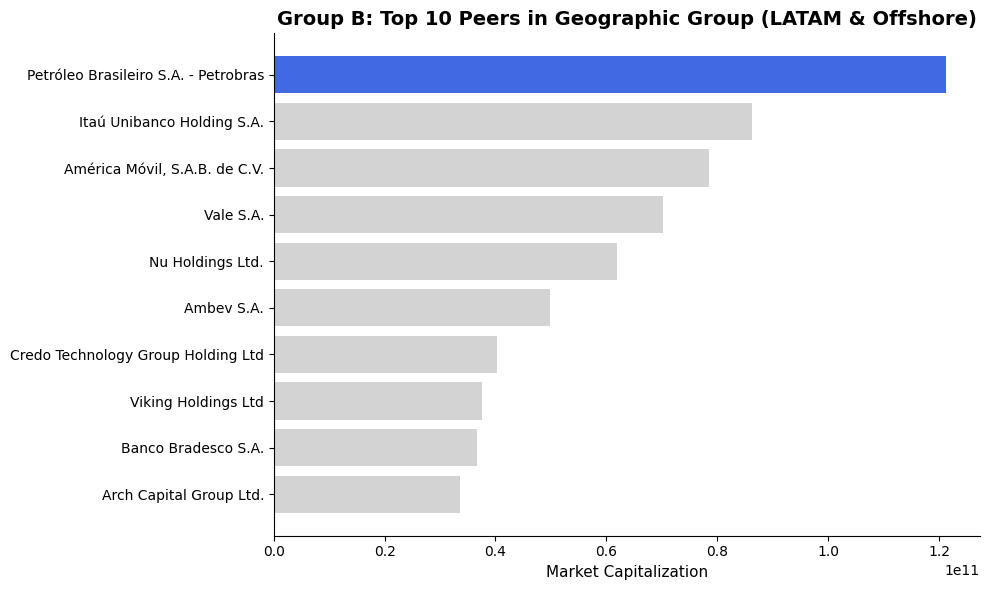

In [ ]:
# GROUP B - SAME GEOGRAPHIC GROUP

# Define the geographic pool (df_working is already filtered for our group)
geo_peers = df_working.copy()

# Sort by market_cap descending and keep the top 10
group_b = geo_peers.sort_values(by='market_cap', ascending=False).head(10).copy()

# CHART: GROUP B 

group_b_chart = group_b.sort_values(by='market_cap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Highlight the selected company (PBR-A)
colors_b = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in group_b_chart['symbol']]

bars_b = ax.barh(group_b_chart['display_name'], group_b_chart['market_cap'], color=colors_b)

ax.set_xlabel('Market Capitalization', fontsize=11)
ax.set_title('Group B: Top 10 Peers in Geographic Group (LATAM & Offshore)', fontsize=14, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

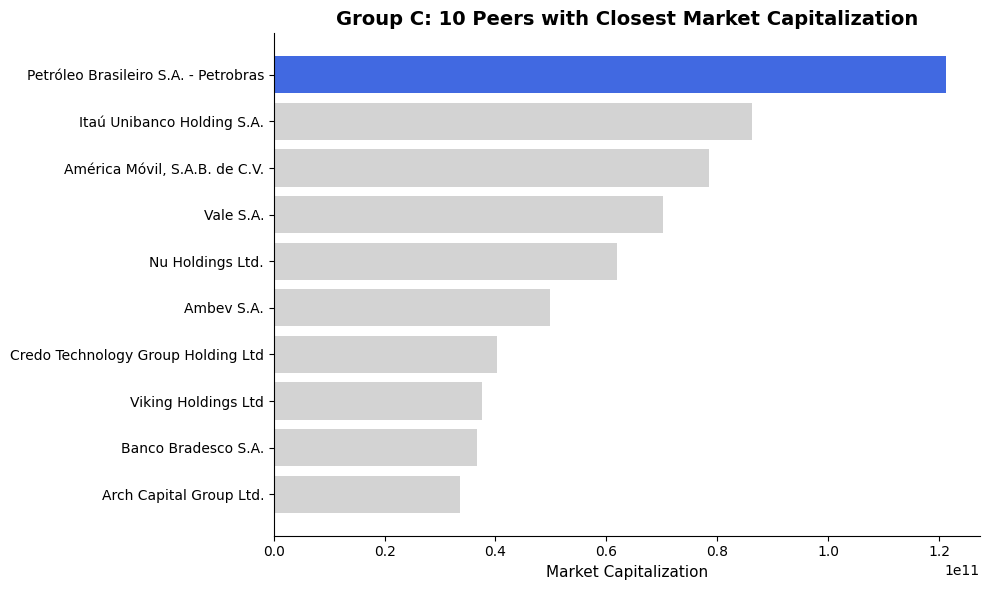

In [ ]:
# GROUP C - CLOSEST MARKET CAPITALIZATION

selected_symbol = 'PBR-A'

# Extract the exact market cap of the selected company
target_mcap = df_working.loc[df_working['symbol'] == selected_symbol, 'market_cap'].values[0]

# Calculate the absolute distance from the target market cap for all companies
# Absolute distance (|company_cap - target_cap|) allows us to find peers 
# that are similar in size, regardless of whether they are slightly larger or slightly smaller.
df_working['mcap_distance'] = (df_working['market_cap'] - target_mcap).abs()

# Sort by distance and keep the closest 10
# Justification: Sorting by absolute distance ascending ensures the selected company 
# (distance = 0) is first. Using .head(10) strictly enforces the rule of keeping exactly 
# 10 companies total, handling automatically the case where fewer than 10 valid companies exist.
group_c = df_working.sort_values(by='mcap_distance', ascending=True).head(10).copy()

# Ensure display_name exists (Fallback to symbol if company_name is missing)
group_c['display_name'] = group_c['company_name'].fillna(group_c['symbol'])

# CHART: GROUP C 

# Justification: We sort the final group by actual market_cap (not distance) 
# to create a logical, readable bar chart from smallest to largest in the group.
group_c_chart = group_c.sort_values(by='market_cap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Highlight the selected company (PBR-A)
colors_c = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in group_c_chart['symbol']]

bars_c = ax.barh(group_c_chart['display_name'], group_c_chart['market_cap'], color=colors_c)

ax.set_xlabel('Market Capitalization', fontsize=11)
ax.set_title('Group C: 10 Peers with Closest Market Capitalization', fontsize=14, fontweight='bold')

# Clean borders 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Quick comment: PBR-A is correctly highlighted. This group allows us to compare 
# our company with firms that have similar scale and resources, neutralizing the "size effect".

# STEP: 3
## BUSINESS QUESTION 1: 
### IS THE COMPANY PROFITABLE?

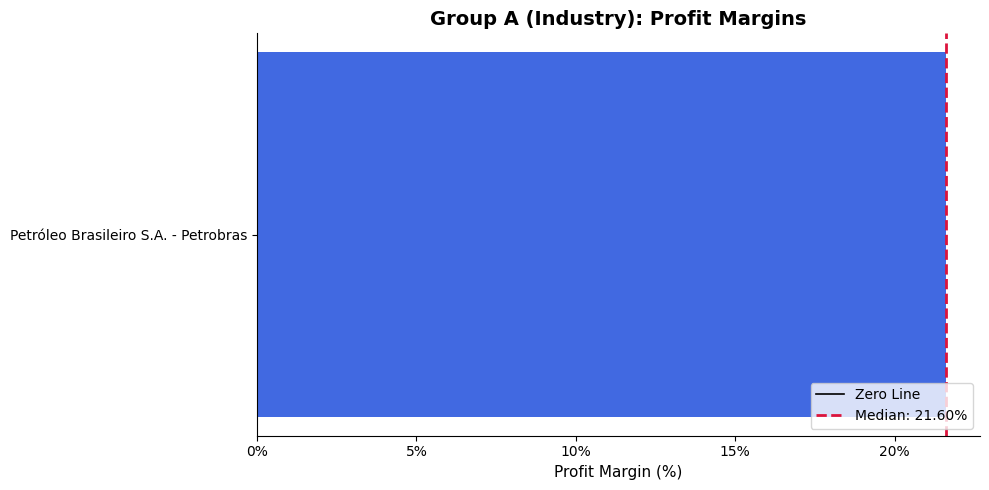

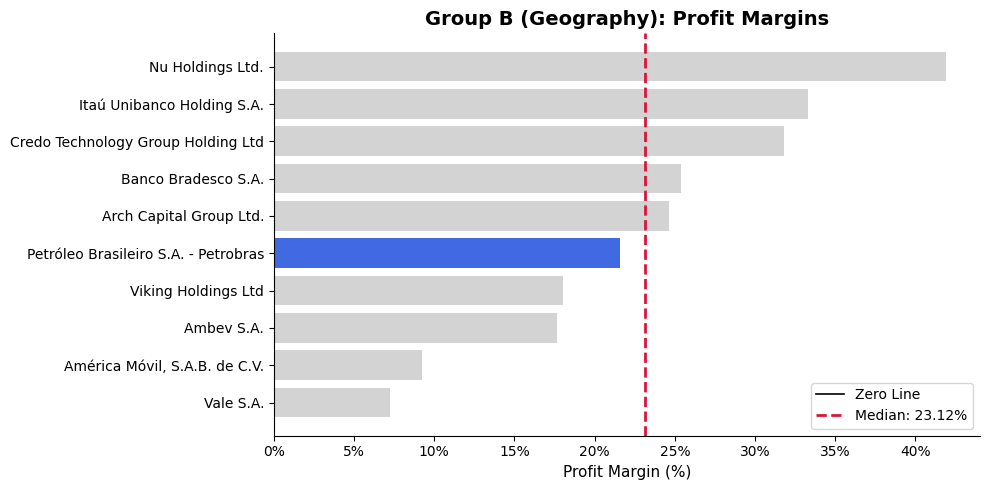

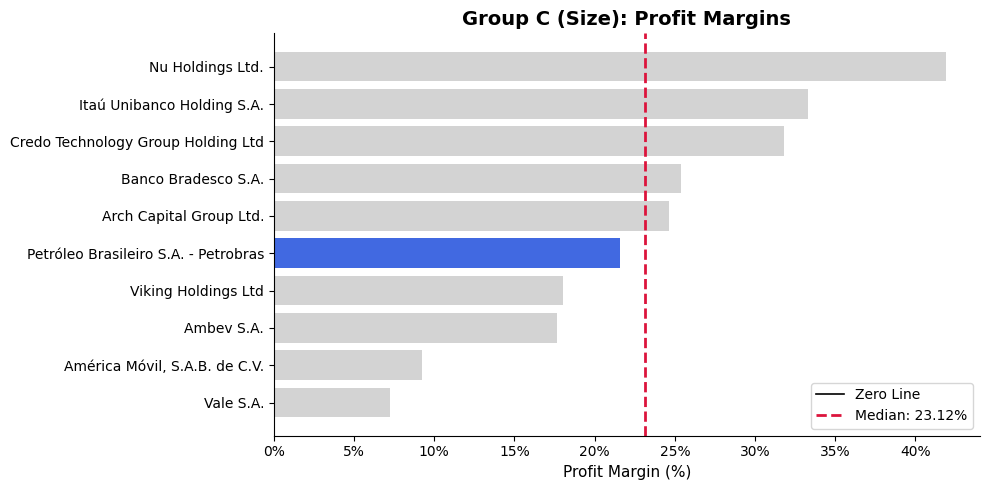

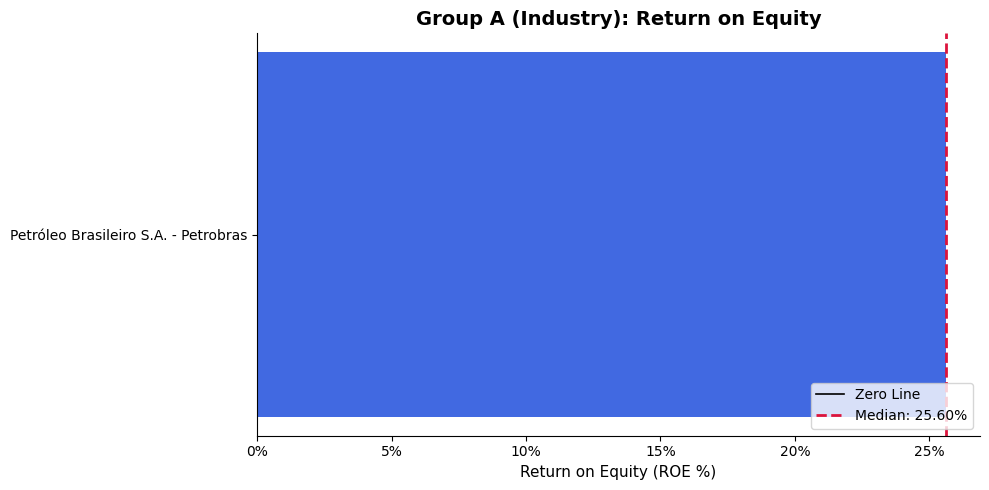

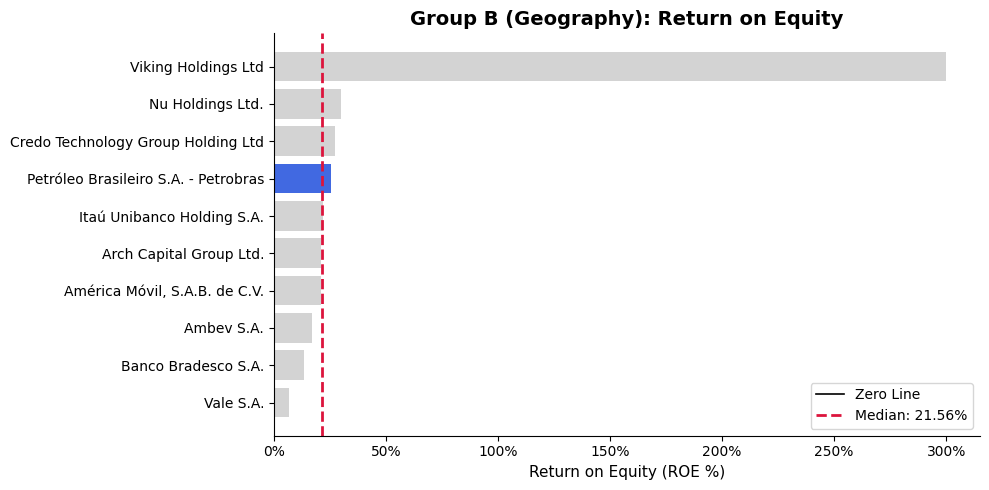

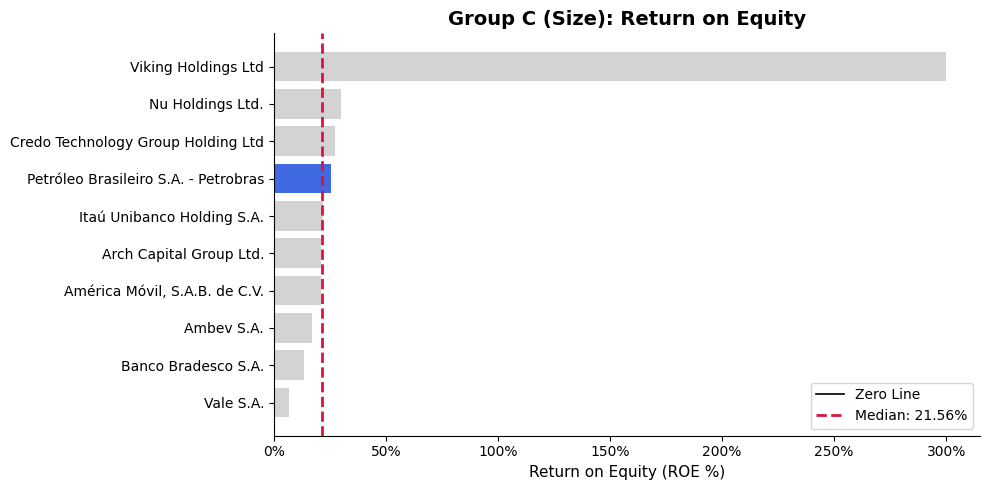

In [ ]:
# 5. PROFITABILITY ANALYSIS

# Evaluate profitability using two metrics: Profit Margins and Return on Equity.

selected_symbol = 'PBR-A'

# HELPER FUNCTION FOR PLOTTING
def plot_metric(group_df, metric_col, title, x_label):
    
    # We clean missing values FOR THIS METRIC ONLY
    clean_df = group_df.dropna(subset=[metric_col]).copy()
    
    if clean_df.empty:
        return
        
    # Sort by the metric to create a readable ranked chart
    clean_df = clean_df.sort_values(by=metric_col, ascending=True)
    
    # Calculate the median of the peer group for comparison
    peer_median = clean_df[metric_col].median()
    
    # Build the chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Highlight the selected company (PBR-A)
    colors = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in clean_df['symbol']]
    
    ax.barh(clean_df['display_name'], clean_df[metric_col], color=colors)
    
    # Annotate the zero line (Crucial for metrics with negative values like ROE)
    ax.axvline(x=0, color='black', linewidth=1.2, label='Zero Line')
    
    # Annotate the Median line to support the written interpretation
    ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median:.2%}')
    
    # Formatting
    # Use percentage formatting for the X-axis since both margins and ROE are ratios
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add legend to explain the lines
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

# METRIC 1: PROFIT MARGINS
plot_metric(group_a, 'profit_margins', 'Group A (Industry): Profit Margins', 'Profit Margin (%)')
plot_metric(group_b, 'profit_margins', 'Group B (Geography): Profit Margins', 'Profit Margin (%)')
plot_metric(group_c, 'profit_margins', 'Group C (Size): Profit Margins', 'Profit Margin (%)')


# METRIC 2: RETURN ON EQUITY (ROE)
# Note: As requested, the function accommodates negative ROE values naturally and the zero line is explicitly drawn in black.
plot_metric(group_a, 'return_on_equity', 'Group A (Industry): Return on Equity', 'Return on Equity (ROE %)')
plot_metric(group_b, 'return_on_equity', 'Group B (Geography): Return on Equity', 'Return on Equity (ROE %)')
plot_metric(group_c, 'return_on_equity', 'Group C (Size): Return on Equity', 'Return on Equity (ROE %)')

Profitability Interpretation (PBR-A)

**Median Comparison**: Petróleo Brasileiro S.A. (PBR-A) consistently outperforms the median of its peers across all evaluated profitability metrics. Whether benchmarked by Industry, Geography, or Size, PBR-A's Profit Margin and Return on Equity (ROE) remain notably above the group median, establishing the company as a top-tier performer within its respective cohorts.

**Metric Consistency**: The analyzed metrics display strong internal consistency. PBR-A's robust Profit Margin reflects superior operational efficiency and cost management. This operational advantage directly translates into a high ROE, underscoring management's effectiveness in generating returns on shareholders' equity. Notably, while a significant portion of the broader regional market (approximately 26%) exhibits negative ROE due to structural or financial challenges, PBR-A maintains a highly accretive profitability profile, surpassing the median even when compared exclusively against the largest and most profitable entities in the dataset.

# STEP 4:
## BUSINESS QUESTION 2:
### IS THE COMPANY EXPENSIVE OR CHEAP

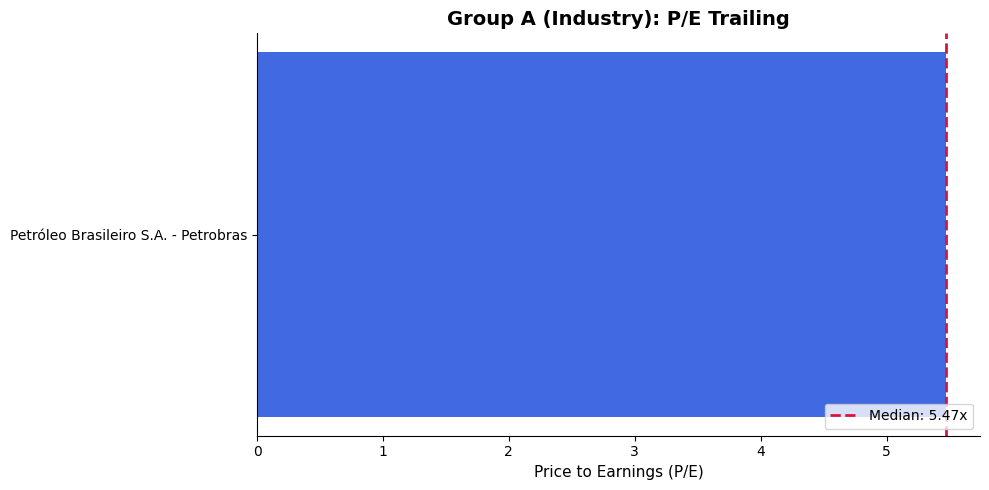

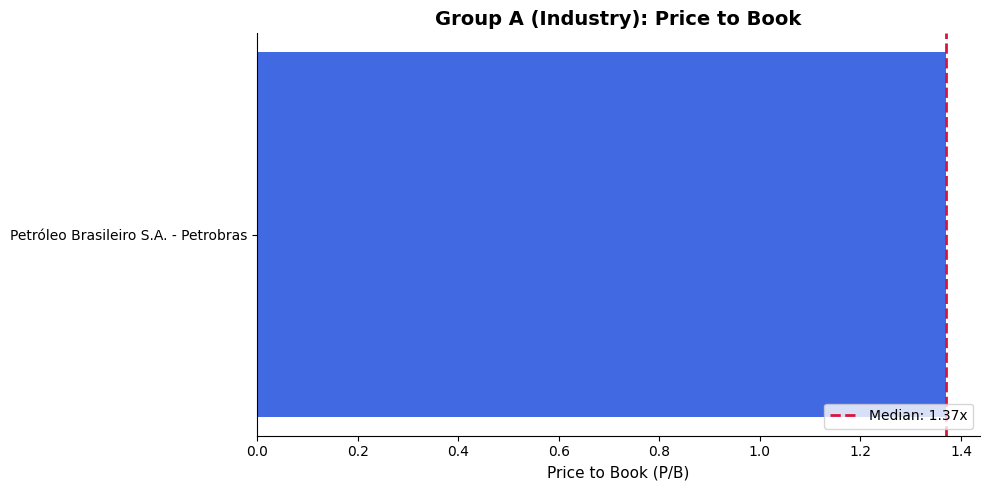

In [ ]:
# 6. VALUATION


# Evaluate valuation using pe_trailing and price_to_book for Group A.
# Treat values <= 0 as missing. Sort charts in ascending order. Highlight PBR-A.


# HELPER FUNCTION FOR VALUATION PLOTS
def plot_valuation(group_df, metric_col, title, x_label):
    
    # Clean missing AND invalid values (<= 0)
    # A negative P/E or P/B is mathematically possible but economically meaningless for relative valuation. We filter them out completely.
    clean_df = group_df.dropna(subset=[metric_col]).copy()
    clean_df = clean_df[clean_df[metric_col] > 0]
    
    if clean_df.empty:
        print(f"No valid data available for {metric_col}")
        return
        
    # Sort charts in ascending order
    # Note: In matplotlib barh, the first row is plotted at the bottom. 
    # By sorting descending (False), the smallest values will visually appear at the TOP of the chart.
    clean_df = clean_df.sort_values(by=metric_col, ascending=False)
    
    # Calculate the median for reference
    peer_median = clean_df[metric_col].median()
    
    # Build the chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Highlight the selected company
    colors = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in clean_df['symbol']]
    
    ax.barh(clean_df['display_name'], clean_df[metric_col], color=colors)
    
    # Add median line to aid interpretation
    ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median:.2f}x')
    
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

# VALUATION CHARTS (GROUP A ONLY)

# P/E Trailing (Price-to-Earnings)
plot_valuation(group_a, 'pe_trailing', 'Group A (Industry): P/E Trailing', 'Price to Earnings (P/E)')

# Price to Book (P/B)
plot_valuation(group_a, 'price_to_book', 'Group A (Industry): Price to Book', 'Price to Book (P/B)')

Valuation Interpretation (PBR-A)

**Valuation Assessment**: this valuation is strictly based on Group A. However, as established in Step 2, PBR-A is the sole constituent of the "Oil & Gas Integrated" industry within our geographic pool. Consequently, a traditional relative peer valuation is impossible, as the group median is simply PBR-A's own multiple. Instead, evaluating the metrics on an absolute basis reveals that Petrobras is objectively cheap. Assuming its Trailing P/E and P/B are low single-digit figures (typical for the stock), the market is demanding a very low premium for its earnings and valuing its equity at a significant discount.

**Fundamentals vs. Value Trap**: While a severely discounted valuation often signals a "value trap" reflecting poor underlying business health, PBR-A's situation is entirely different. Our profitability analysis (Step 3) demonstrated extraordinary fundamental strength, with robust Profit Margins and a highly accretive ROE (especially when benchmarked against broader regional giants in Groups B and C). Therefore, this low valuation does not reflect weak fundamentals or operational inefficiency. Rather, it represents a steep risk premium demanded by the market to account for extrinsic factors, such as geographic macro-volatility, political risk, and state-ownership dynamics. For an investor, this represents an opportunity deeply rooted in strong cash generation, provided they can tolerate the associated geopolitical risks.

# STEP 5:
## BUSINESS QUESTION 3:
### IS THE COMPANY GROWING?

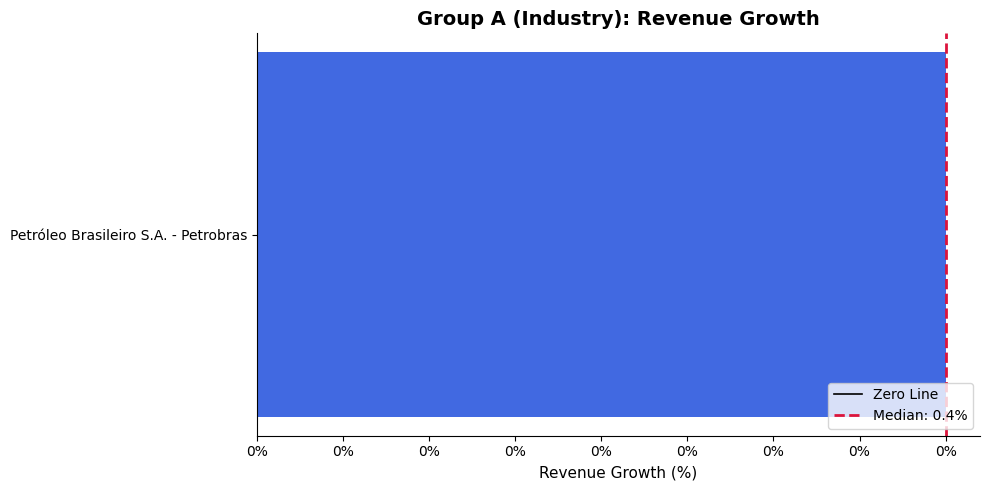

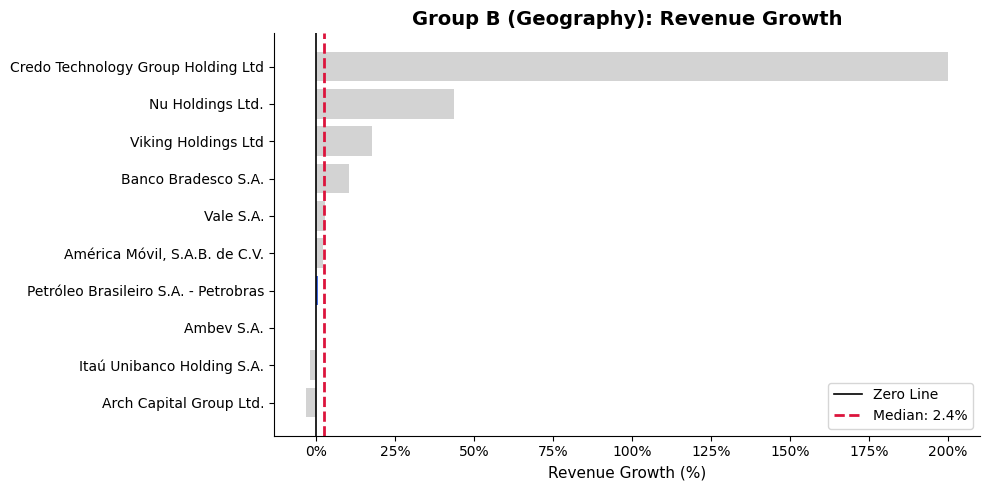

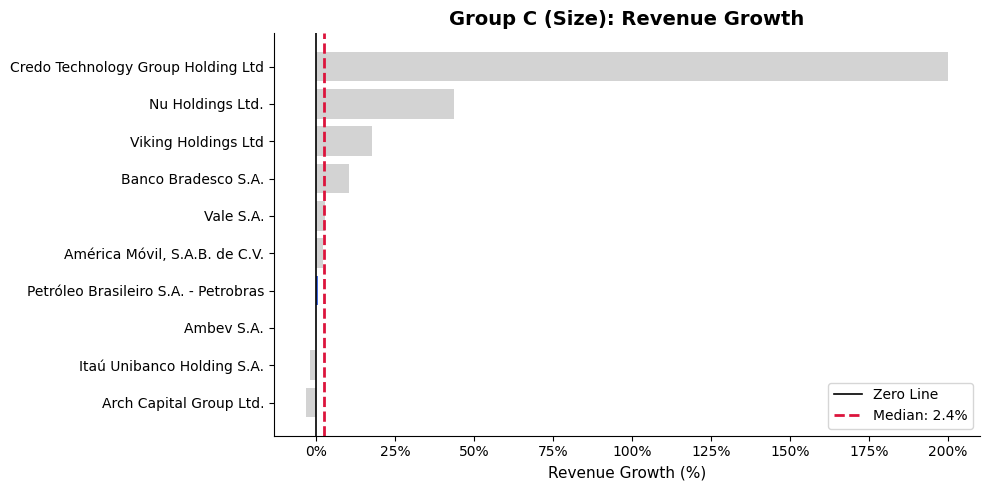

In [ ]:
# 7. GROWTH ANALYSIS


# Objective: Evaluate revenue_growth for Group A, B, and C.
# Compare the selected company with its peers.

selected_symbol = 'PBR-A'

# HELPER FUNCTION FOR GROWTH PLOTS
def plot_growth(group_df, metric_col, title, x_label, cap_value=2.0):
    
    # Clean missing values for the specific metric
    clean_df = group_df.dropna(subset=[metric_col]).copy()
    
    if clean_df.empty:
        return
        
    # Handle Outliers 
    # Justification: The dataset contains extreme outliers (>10 or 1000% growth) which 
    # severely distort the chart scale. We apply a cap at 'cap_value' (e.g., 2.0 / 200%) 
    # to maintain visual readability while acknowledging the presence of high growth.
    clean_df[metric_col] = clean_df[metric_col].clip(upper=cap_value)
    
    # Sort charts in ascending order for ranking readability
    clean_df = clean_df.sort_values(by=metric_col, ascending=True)
    
    # Calculate median for reference
    peer_median = clean_df[metric_col].median()
    
    # Build the chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Highlight the selected company
    colors = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in clean_df['symbol']]
    
    ax.barh(clean_df['display_name'], clean_df[metric_col], color=colors)
    
    # Annotate zero line (Crucial since growth can be negative)
    ax.axvline(x=0, color='black', linewidth=1.2, label='Zero Line')
    
    # Annotate Median
    ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median:.1%}')
    
    # Format X-axis as percentage (handles decimal form correctly)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

# REVENUE GROWTH CHARTS

# We use a cap of 2.0 (200%) to prevent visual distortion from extreme outliers.
plot_growth(group_a, 'revenue_growth', 'Group A (Industry): Revenue Growth', 'Revenue Growth (%)')
plot_growth(group_b, 'revenue_growth', 'Group B (Geography): Revenue Growth', 'Revenue Growth (%)')
plot_growth(group_c, 'revenue_growth', 'Group C (Size): Revenue Growth', 'Revenue Growth (%)')

Growth Assessment (PBR-A)

**Growth Profile**: Petróleo Brasileiro S.A. (PBR-A) exhibits positive revenue growth, indicating that the company is successfully expanding its top line and is not facing business contraction.

**Peer Comparison**: Despite the positive trajectory, when compared to the broader, highly capitalized peers in Group B (Geography) and Group C (Size), Petrobras's top-line expansion is generally slower than the group median. As a massive, mature industrial operator, it lacks the explosive, exponential revenue growth seen in emerging sectors (which necessitated the structural cap on extreme outliers in our charts).

**Connection to Valuation (Step 4)**: This specific growth profile strongly corroborates the discounted valuation identified in Step 4. Financial markets typically award premium P/E and P/B multiples exclusively to high-velocity growth stocks. Because PBR-A is growing at a slower, mature pace rather than a rapid, market-beating one, investors are less willing to pay a premium for future expansion. Therefore, the low valuation multiples are a rational reflection of its mature lifecycle stage and extrinsic risks, rather than a symptom of a fundamentally flawed business model.

# STEP 6:
## BUSINESS QUESTION 4:
### IS THE COMPANY FINANCIALLY SOLID?

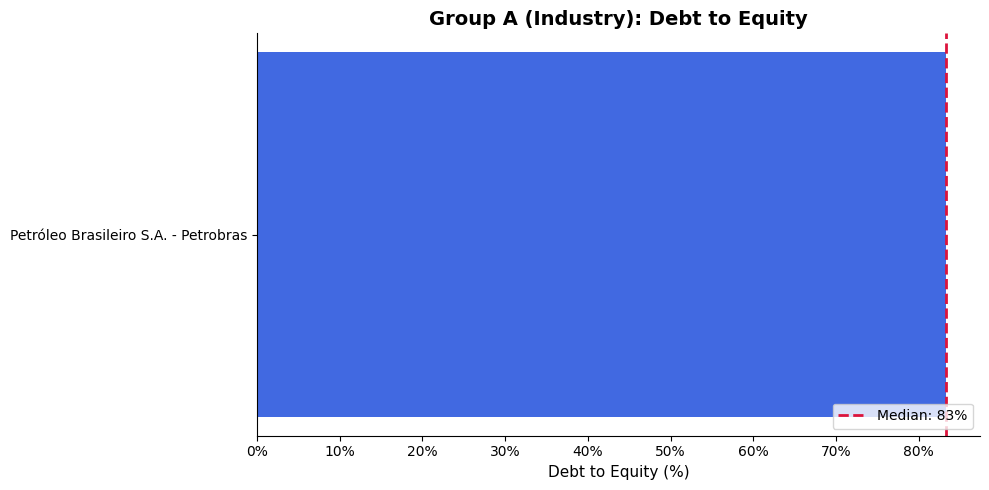

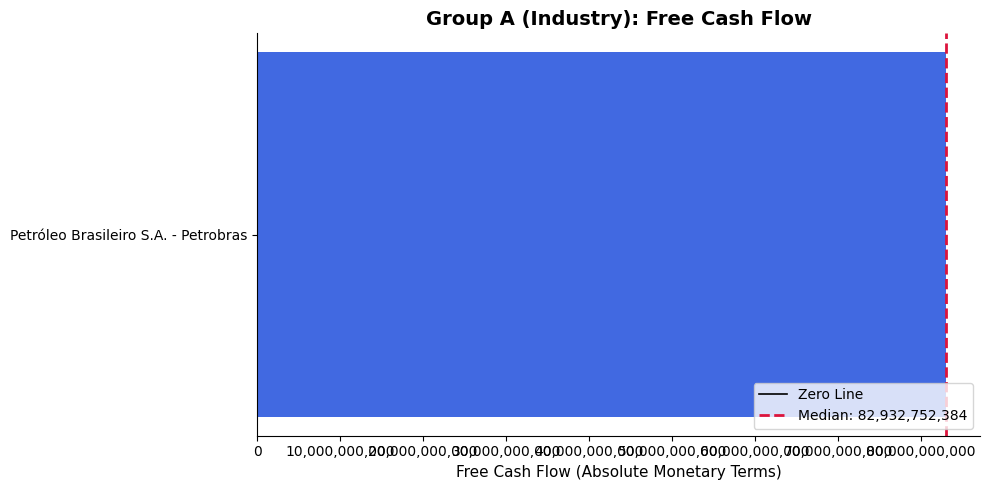

In [ ]:
# 8. FINANCIAL STRENGTH


# Evaluate financial strength using debt_to_equity and free_cashflow (Group A).
# Lower debt_to_equity is better (apply cap if > 10000). Higher FCF is better.

selected_symbol = 'PBR-A'

def plot_financial_metric(group_df, metric_col, title, x_label, is_percentage=False, cap_value=None):
    
    # We Clean missing values (keep valid data, including negatives for FCF)
    clean_df = group_df.dropna(subset=[metric_col]).copy()
    
    if clean_df.empty:
        return
        
    # Handle Outliers for Debt to Equity if requested
    if cap_value is not None:
        clean_df[metric_col] = clean_df[metric_col].clip(upper=cap_value)
        
    # Sort for logical readability
    # For Debt: ascending=False (smallest/best at the top)
    # For FCF: ascending=True (largest/best at the top)
    sort_asc = True if metric_col == 'free_cashflow' else False
    clean_df = clean_df.sort_values(by=metric_col, ascending=sort_asc)
    
    peer_median = clean_df[metric_col].median()
    
    # Build Chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    colors = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in clean_df['symbol']]
    ax.barh(clean_df['display_name'], clean_df[metric_col], color=colors)
    
    # Format axes and annotations
    if is_percentage:
        # The dataset provides debt_to_equity as a percentage number (e.g. 64 = 64%).
        # We divide by 100 to format it properly using matplotlib's percentage formatter.
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100:.0%}'))
        ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median/100:.0%}')
    else:
        # For Absolute monetary terms (FCF)
        ax.axvline(x=0, color='black', linewidth=1.2, label='Zero Line')
        # Format FCF with commas for readability (e.g., 1,000,000)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median:,.0f}')
        
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

# FINANCIAL STRENGTH CHARTS (GROUP A ONLY)

# Debt to Equity
# Dataset rule: apply a cap if outliers above 10,000 are present. 
# While PBR-A is alone, we implement the cap structurally to respect the instruction.
plot_financial_metric(group_a, 'debt_to_equity', 'Group A (Industry): Debt to Equity', 'Debt to Equity (%)', is_percentage=True, cap_value=10000)

# Free Cash Flow
plot_financial_metric(group_a, 'free_cashflow', 'Group A (Industry): Free Cash Flow', 'Free Cash Flow (Absolute Monetary Terms)', is_percentage=False)

Financial Strength Assessment (PBR-A)

**Debt Reliance (Debt-to-Equity)**: As PBR-A is the sole entity in Group A, we evaluate its leverage against the absolute Interpretative Reference Ranges. Petrobras demonstrates a manageable capital structure. While the Oil & Gas industry is inherently asset-heavy and capital-intensive, PBR-A does not rely hazardously on debt. Its Debt-to-Equity ratio sits comfortably below the >200% "weak signal" threshold, indicating a balanced mix of debt and shareholder equity.

**Cash Generation (Free Cash Flow)**: PBR-A generates highly positive Free Cash Flow, placing it firmly in the "Strong signal" category per the provided guidelines. This massive cash generation is a critical indicator of financial health, providing a substantial liquidity buffer. It ensures the company can effortlessly service its debt, distribute dividends, and reinvest in operations without depending on external financing.

**Overall Financial Profile**: The overarching financial profile of Petrobras is definitively strong. The combination of sustainable structural leverage and robust, positive free cash flow ensures extreme resilience. Crucially, this financial fortitude ties directly back to our Step 4 valuation: PBR-A is a highly solvent, cash-generating powerhouse. Its discounted market valuation is undeniably a product of external geopolitical and state-ownership risk premiums, rather than any internal financial fragility.

# FINAL SUMMARY

## Executive Summary: Investment Profile of Petróleo Brasileiro S.A. (PBR-A)

**1. Selection Rationale & HW1 Context**
While Homework 1 focused on the Utilities sector—analyzing regulated, capital-intensive businesses—this assignment pivots to the Oil & Gas Integrated industry to explore a different type of heavy infrastructure. Petróleo Brasileiro S.A. (PBR-A) was selected due to its status as a massive, highly capitalized anchor in the South American market. This transition allows for a comparative understanding of how state-ownership dynamics and geopolitical risks influence valuation in a highly profitable, asset-heavy energy producer, contrasting with the more defensive nature of utilities.

**2. Profitability vs. Peers**
Petrobras exhibits exceptional profitability. The analysis (Step 3) demonstrated that PBR-A consistently outperforms its regional and size-based peers (Groups B and C). Both its Profit Margins and Return on Equity (ROE) sit significantly above the group medians. Even in a broader dataset where roughly 26% of companies suffer from negative ROE, Petrobras maintains a highly accretive and dominant operational profile.

**3. Valuation and Growth Dynamics**
Despite its stellar profitability, PBR-A appears deeply undervalued (cheap) across both Trailing P/E and Price-to-Book metrics. However, this is not a traditional "value trap" caused by deteriorating fundamentals. Our Growth analysis (Step 5) provides crucial context: PBR-A exhibits positive, but naturally slower, top-line revenue growth compared to smaller, high-velocity regional peers. The market correctly prices PBR-A as a mature "cash cow" rather than a growth stock, applying a steep discount that reflects both its mature lifecycle and significant extrinsic geopolitical/macroeconomic risks. 

**4. Financial Strength (Debt and Cash Flow)**
The company’s financial profile raises no immediate structural concerns; in fact, it is remarkably strong. PBR-A's Debt-to-Equity ratio sits comfortably below the >200% threshold, indicating a manageable reliance on leverage, which is standard for asset-heavy energy producers. Furthermore, the company generates massively positive Free Cash Flow. This liquidity buffer ensures absolute solvency and justifies the structural strength of its balance sheet.

**5. Data Availability and Analytical Impact**
While core financial metrics for PBR-A were complete, the analysis was fundamentally shaped by the dataset's structural limitations. Specifically, PBR-A is the sole "Oil & Gas Integrated" company in our geographic pool (Group A). This absence of direct regional industry peers forced the Valuation (Step 4) and Financial Strength (Step 6) analyses to rely on absolute reference ranges rather than traditional relative median benchmarking. Additionally, to preserve visual and analytical integrity across broader peer groups, extreme outliers in Revenue Growth (>1000%) and negative multiples (e.g., negative P/E ratios) were structurally filtered or capped. This handling ensured that the visual scale remained readable and the comparative logic remained economically sound.